**Jacob Petty, Sardor Nodirov and Saad Khan**

Spring 2026

CS 443: Bio-inspired Machine Learning

Project 2: Predictive Coding

#### Week 2: Predictive coding: classification and image generation

With the Dense PCN built, let's analyze its classification accuracy on MNIST and CIFAR-10 and explore its generative image capabilities. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

plt.style.use(['seaborn-v0_8-colorblind', 'seaborn-v0_8-darkgrid'])
plt.show()
plt.rcParams.update({'font.size': 18})

np.set_printoptions(suppress=True, precision=3)

%load_ext autoreload
%autoreload 2

## Task 3: Dense PCN and MNIST

Now you are ready to train your Dense PCN on MNIST!

In addition to optimizing the classification accuracy, you will:
1. visualize the "ideal" digit that each output neuron of a trained net "expects to see".
2. leverage this generative capability of PCNs to "fill in" blanked out parts of test samples.

In [2]:
from image_datasets import get_dataset, train_val_split
from dense_pcn import DensePCN

### 3a. Train and evaluate classification accuracy on MNIST

In the cell below, train a Dense PCN with 1 hidden layer on *centered* preprocessed MNIST samples with the default train/val/test split.

Your goal is to play with the following hyperparameters to obtain **≥75% accuracy on the test set**:
- number of epochs
- batch size
- number of units

Fix your learning rate to `1e-4` and use the default number of train/test feedback iterations.

Be sure to print out your test accuracy.


**Notes:**
- If your training is working properly, you should see your training loss consistently decline.
- You should not need to train for many epochs to hit the accuracy target. 
- I suggest setting a random seed so that similar to the test code your results do not fluctuate based on differences in initial random weights between runs.

In [3]:
tf.random.set_seed(0)

x_train, y_train, x_test, y_test = get_dataset('mnist', norm_method='center')
x_train, y_train, x_val, y_val = train_val_split(x_train, y_train)

net = DensePCN(input_feats_shape=(784,), C=10, hidden_units=(256,), wt_scale=1e-2, gamma_lr=0.1,
               train_num_steps=20, test_num_steps=20)
net.compile(loss='predictive', lr=1e-4)

Loaded MNIST dataset
  x_train shape: (60000, 28, 28), dtype: uint8
  y_train shape: (60000,), dtype: uint8
  x_test shape: (10000, 28, 28), dtype: uint8
  y_test shape: (10000,), dtype: uint8

After min-max normalization to [0, 1]:
  x_train range: [0.0000, 1.0000]

Centering stats (computed from training set):
  Mean per channel: 0.13066062331199646

After centering:
  x_train mean: -0.000000
  x_test mean: 0.001854

After flattening:
  x_train shape: (60000, 784)
  x_test shape: (10000, 784)


I0000 00:00:1775114900.173298 2676419 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1775114900.173507 2676419 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)



Final tensor shapes and dtypes:
  x_train: (60000, 784), <dtype: 'float32'>
  y_train: (60000,), <dtype: 'int32'>
  x_test: (10000, 784), <dtype: 'float32'>
  y_test: (10000,), <dtype: 'int32'>
---------------------------------------------------------------------------
OutputLayer (10 units). Output shape: [1, 10]
PredLayer_0 (256 units). Output shape: [1, 256]
InputLayer (784 units). Output shape: [1, 784]
---------------------------------------------------------------------------


In [5]:
train_loss_hist, val_loss_hist, val_acc_hist, n_epochs = net.fit(
    x_train, y_train, x_val=x_val, y_val=y_val,
    batch_size=128, max_epochs=5, val_every=1
)

test_acc, test_loss = net.evaluate(x_test, y_test)
print(f'\nTest accuracy: {test_acc}')
print(f'Test loss: {test_loss}')

Epoch 1/5, Training loss 16.422, Val loss 11.088, Val acc 0.7913. Epoch took: 19.8 secs
Epoch 2/5, Training loss 10.170, Val loss 8.595, Val acc 0.8328. Epoch took: 19.3 secs
Epoch 3/5, Training loss 7.545, Val loss 7.050, Val acc 0.8330. Epoch took: 19.4 secs
Epoch 4/5, Training loss 6.071, Val loss 6.036, Val acc 0.8236. Epoch took: 19.5 secs
Epoch 5/5, Training loss 5.167, Val loss 5.371, Val acc 0.8167. Epoch took: 19.5 secs
Training finished after 5 epochs in 112.09 seconds
The learning rate was decayed 0 times.

Test accuracy: 0.7852564102564102
Test loss: 5.311573028564453


### 3b. Hyperparameter tuning: test steps

With the same hyperparameters that you used in the previous subtask, run inference on your Dense PCN to compute the test accuracy with the following number of test steps: `1, 10, 20, 30, ..., 100`.

Make a plot showing the MNIST test accuracy in each case.

Test steps: 1, Test accuracy: 0.7548076923076923
Test steps: 10, Test accuracy: 0.8083934294871795
Test steps: 20, Test accuracy: 0.7852564102564102
Test steps: 30, Test accuracy: 0.7746394230769231
Test steps: 40, Test accuracy: 0.7757411858974359
Test steps: 50, Test accuracy: 0.7799479166666666
Test steps: 60, Test accuracy: 0.7841546474358975
Test steps: 70, Test accuracy: 0.7875600961538461
Test steps: 80, Test accuracy: 0.7908653846153846
Test steps: 90, Test accuracy: 0.793770032051282
Test steps: 100, Test accuracy: 0.7955729166666666


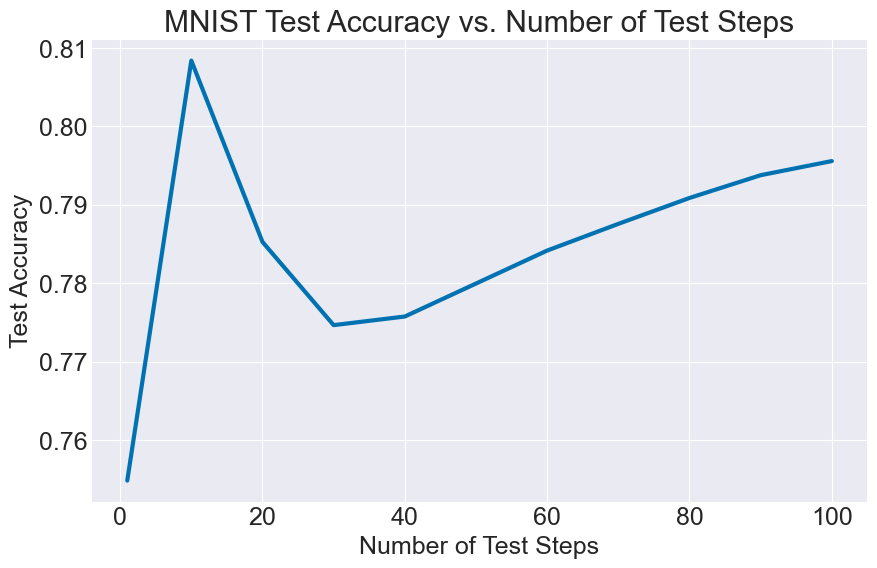

In [7]:
test_steps_list = [1, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
test_accs = []

for n_steps in test_steps_list:
    net.set_test_num_steps(n_steps)
    acc, loss = net.evaluate(x_test, y_test)
    test_accs.append(acc)
    print(f'Test steps: {n_steps}, Test accuracy: {acc}')

plt.figure(figsize=(10, 6))
plt.plot(test_steps_list, test_accs, linewidth=3)
plt.xlabel('Number of Test Steps')
plt.ylabel('Test Accuracy')
plt.title('MNIST Test Accuracy vs. Number of Test Steps')
plt.grid(True)
plt.show()

### 3c. Questions

**Question 2:** (a) What number of test steps produced the optimal test accuracy for you? (b) What was the best test accuracy that you achieved and how does that compare to the baseline that you found in the previous subtask?

**Question 3:** Compared to the baseline number of steps, why would the larger (or smaller) number of steps lead to improved accuracy in the PCN?

**Answer 2:** From the graph above we can see a pointy peak at  10 test steps which showed the best result at almost 0.81, after which it quickly falls down to ~ 0.78. Overall, I'd say 10 test steps and anything over 60 showed an improvement compared to the baselines.


**Answer 3:** In a PCN, classification at test time relies on iteratively settling the states across all layers to minimize total prediction error. When the steps are too few, the states may not have yet converged, and so the output layer state may not accurately reflect the correct class because the feedback and feedforward prediction errors have not been fully reconciled. More steps give the recurrent dynamics time to propagate information between layers, allowing the output state to better align with the true class. But also, too many steps can occasionally cause the states to overshoot or oscillate.

### 3d. Expected class images

Follow the inline instructions to finish the implementation of the `dream_input` method in the `DensePCN` class. Afterwards, run the code provided below to visualize the expected input for each output neuron of your PCN!

*You should see a very cool ~30 sec animation when running the cell below.*

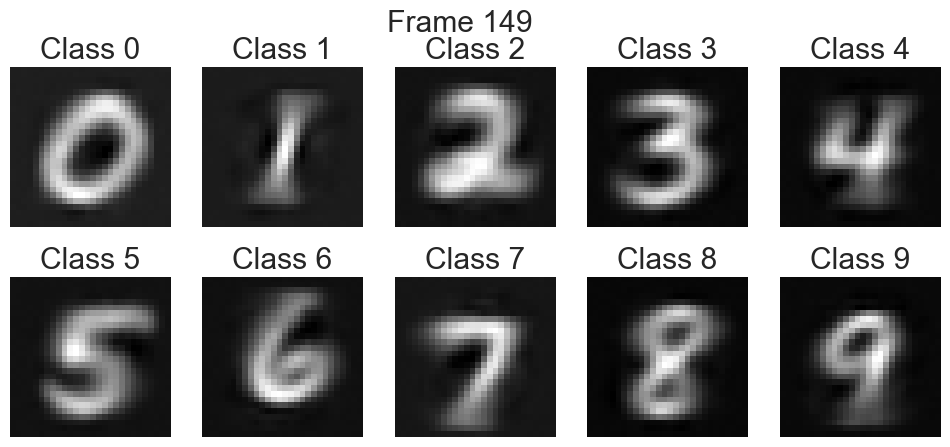

In [9]:
# Keep me
class_names = tf.range(10)
net.dream_input(class_names)

### 3e. Questions

**Question 4:** Describe what you see in the animation and interpret what it means (i.e. why do you see what you see in each figure panel in the order in which you see it).

**Answer 4:** The animation showed 10 digits (classes) slowly turn from noise into legible digits. The process looked starkingly similar to how diffusion models generate images from noise. Under the hood, as the iterations progressed, the prediction errors between layers got minimized and the input state converged toward the image that the network "expects" to see for that class. At the end, we have an expected or even ideal shape a particular digit is expected to have. This occurs because each output neuron is clamped to 1 (with all others at 0), and the network's learned weights propagate this top-down signal backward through the hidden layers to the input layer.

### 3f. Filling in occluded parts of images

This subtask focuses on a neat application of the generative capabilities of PCNs — filling in or completing parts of test images that are *missing* (i.e. blanked out). 

#### (i) Visualizing occluded MNIST images

Run the cell below to generate versions of test set images in which the top half of pixels is blanked (**masked**) out.

*For the first few MNIST test set images, you should see the original image (top), occluded image (middle) and the occlusion mask used to generate the occluded image (bottom). In this plotting convention, parts of the mask that zero out corresponding parts of each image sample are black (0s) and parts that preserve the image data are white (1s).*

In [10]:
from image_datasets import occlude_images

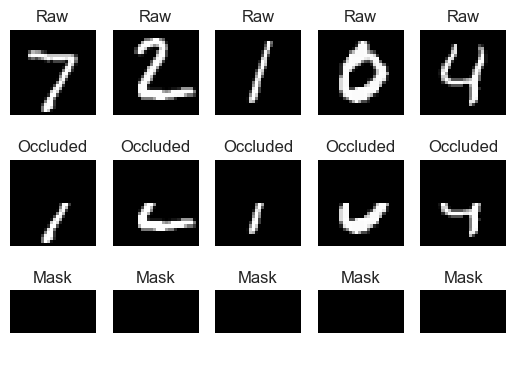

In [11]:
x_test_occ, masks = occlude_images(x_test, region='top')

items = [x_test, x_test_occ, masks]
labels = ['Raw', 'Occluded', 'Mask']

num_samples = 5
fig, axes = plt.subplots(3, num_samples)
for i in range(num_samples):
    for j in range(3):
        axes[j, i].imshow(tf.reshape(items[j][i], (28, 28)), cmap='gray')
        axes[j, i].set_title(labels[j], fontsize=12)
        axes[j, i].grid(False)
        axes[j, i].set_xticks([])
        axes[j, i].set_yticks([])

plt.show()

#### (ii) Add support for dreaming in masked parts of images

We will use your PCN's generative dreaming capability to "fill in" the occluded parts of the image based on the available information and the net's expectation for what should appear in the occluded image regions. For this to work, we need to slightly modify how your `InputPCNLayer` modifies its state: we ONLY want to have the net dream in MASKED parts of the image (non-occluded raw pixels should remain untouched as the state is updated).

In `InputPCNLayer` make the following small updates:
1. Implement `set_mask` to create an instance variable to store the masks for each test set mini-batch.
2. Modify `update_state` to use the occlusion mask to zero out the *top-down prediction error* in places where the input images were NOT MASKED by the occlusion mask (i.e. in places where there is actual useful image data). If there is no mask, modify the state like usual.

#### (iii) Finish method to fill in masked regions of image and animate the process

Follow the inline instructions to finish the implementation of the `complete_input` method in the `DensePCN` class, which will fill in the occluded parts of MNIST images.

Run the following code to animate the filling in process. *You should see a ~30 sec animation.*

**Note:** Replace `net` with your trained net's name.


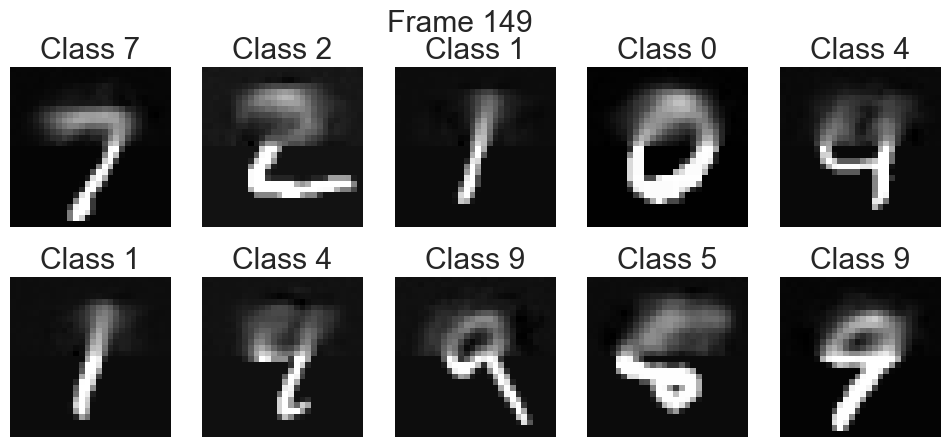

In [12]:
min_ind = 0
max_ind = 10
net.complete_input(x_test_occ[min_ind:max_ind],
                   masks[min_ind:max_ind],
                   y_test[min_ind:max_ind])

### 3g. Questions

**Question 5:**

(a) How closely do the filled in images resemble the original images?

(b) How sensible/plausible are the filled in content by the network?

**Answer 5:** It got the overall shape and the stroke width, but obviously struggled a little with odd instances like 0's hat. For digit 4, it seemed to perform worse, possibly because of two parallel lines.

(b) Overall, I think the network has done an amazing job. Yes, it still looks blurry but the general shape and stroke was recovered quite nicely.

## Task 4: Dense PCN and CIFAR-10

This task focuses on evaluating the classification accuracy of your dense PCN on CIFAR-10. You will also visualize the expected images corresponding to each output neuron.

### 4a. Train and evaluate classification accuracy on CIFAR-10

In the cell below, train a Dense PCN with 1 hidden layer on *centered* preprocessed CIFAR-10 samples with the default train/val/test split.

Use default hyperparameters, except for the following:
- `10` epochs.
- Batch size of `256`.
- Learning rate of `1e-4`.

Print out the accuracy that you obtain on the test set. If everything is working as expected, you should be able to obtain **test accuracy ≥ 25%**.

In [14]:
tf.random.set_seed(0)

x_train_c, y_train_c, x_test_c, y_test_c = get_dataset('cifar10', norm_method='center')
x_train_c, y_train_c, x_val_c, y_val_c = train_val_split(x_train_c, y_train_c)

net = DensePCN(input_feats_shape=(3072,), C=10, hidden_units=(256,), wt_scale=1e-2, gamma_lr=0.1,
               train_num_steps=20, test_num_steps=20)
net.compile(loss='predictive', lr=1e-4)

Loaded CIFAR10 dataset
  x_train shape: (50000, 32, 32, 3), dtype: uint8
  y_train shape: (50000,), dtype: uint8
  x_test shape: (10000, 32, 32, 3), dtype: uint8
  y_test shape: (10000,), dtype: uint8

After min-max normalization to [0, 1]:
  x_train range: [0.0000, 1.0000]

Centering stats (computed from training set):
  Mean per channel: [0.491 0.482 0.447]

After centering:
  x_train mean: -0.000001
  x_test mean: 0.003221

After flattening:
  x_train shape: (50000, 3072)
  x_test shape: (10000, 3072)

Final tensor shapes and dtypes:
  x_train: (50000, 3072), <dtype: 'float32'>
  y_train: (50000,), <dtype: 'int32'>
  x_test: (10000, 3072), <dtype: 'float32'>
  y_test: (10000,), <dtype: 'int32'>
---------------------------------------------------------------------------
OutputLayer (10 units). Output shape: [1, 10]
PredLayer_0 (256 units). Output shape: [1, 256]
InputLayer (3072 units). Output shape: [1, 3072]
--------------------------------------------------------------------------

In [16]:
train_loss_hist, val_loss_hist, val_acc_hist, n_epochs = net.fit(
    x_train_c, y_train_c, x_val=x_val_c, y_val=y_val_c,
    batch_size=256, max_epochs=10, val_every=1
)

test_acc, test_loss = net.evaluate(x_test_c, y_test_c)
print(f'\nTest accuracy: {test_acc}')
print(f'Test loss: {test_loss}')

Epoch 1/10, Training loss 36.714, Val loss 33.863, Val acc 0.2548. Epoch took: 8.5 secs
Epoch 2/10, Training loss 26.872, Val loss 30.649, Val acc 0.2871. Epoch took: 9.1 secs
Epoch 3/10, Training loss 22.436, Val loss 24.456, Val acc 0.2819. Epoch took: 8.7 secs
Epoch 4/10, Training loss 19.747, Val loss 20.574, Val acc 0.2770. Epoch took: 8.5 secs
Epoch 5/10, Training loss 17.711, Val loss 18.439, Val acc 0.2790. Epoch took: 8.5 secs
Epoch 6/10, Training loss 16.362, Val loss 16.879, Val acc 0.2798. Epoch took: 8.5 secs
Epoch 7/10, Training loss 15.154, Val loss 15.770, Val acc 0.2800. Epoch took: 8.6 secs
Epoch 8/10, Training loss 14.313, Val loss 14.864, Val acc 0.2762. Epoch took: 8.9 secs
Epoch 9/10, Training loss 13.603, Val loss 14.130, Val acc 0.2714. Epoch took: 9.0 secs
Epoch 10/10, Training loss 12.904, Val loss 13.496, Val acc 0.2686. Epoch took: 8.8 secs
Training finished after 10 epochs in 113.54 seconds
The learning rate was decayed 0 times.

Test accuracy: 0.2644230769

### 4b. Visualize expected inputs for each output neuron

Running the following code should show an animation of the expected input according to each output neuron of your trained PCN.

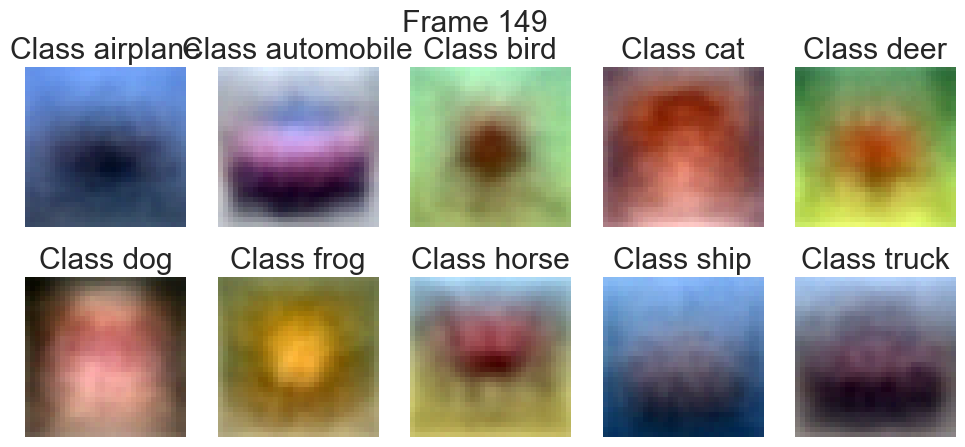

In [17]:
cifar_class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
net.dream_input(cifar_class_names, image_dims=(32, 32, 3))

### 4c. Questions

**Question 6:** Why are the expected inputs for each class blurrier than those that you generated for MNIST?

**Question 7:** Why might the blurriness of expected images of each class hinder the potential for feedback in the PCN to raise the classification accuracy?

**Answer 6:** MNIST is a digits-only database with stark and legible symbols. Jus by the nature of digits having a strict overall pattern with not significant variation between the samples, allows the model to get the average ("ideal") model of the classes best. This is not the case for the images. The variation between the samples within the classes are often too big to yield high definition results. But even then, it's nice that we can make out some general patterns out of the learned weights, like red car in the automobile class or a brownish spot on the green background for the deer class.

**Answer 7:** The feedback mechanism in a PCN works by generating top-down predictions of what the input should look like for each class and then computing prediction errors against the actual input. When the expected images are sharp and distinct (as in MNIST), the prediction errors meaningfully differentiate between classes, or in the other words, the error will be small for the correct class and large for incorrect ones. However, when the expected images are blurry (as in CIFAR-10), the top-down predictions are vague and look similar across different classes. This means the prediction errors become less discriminative and the difference between the prediction error for the correct class and an incorrect class is smaller. As a result, the feedback signal provides less useful information for refining the output layer states during inference, limiting the PCN's ability to leverage its iterative state updates to improve classification accuracy beyond what the initial feedforward pass achieves.